<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana2/RegresionMultipleCarro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Necesitamos explorar la estructura de directorios
import os
# Necesito ir a la carpeta del curso
os.chdir('/content/drive/MyDrive/EDCO_MachineLearning/Semana2/')

In [4]:
datos = pd.read_csv('Datos/Auto_MPG_UCI.csv')
datos

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


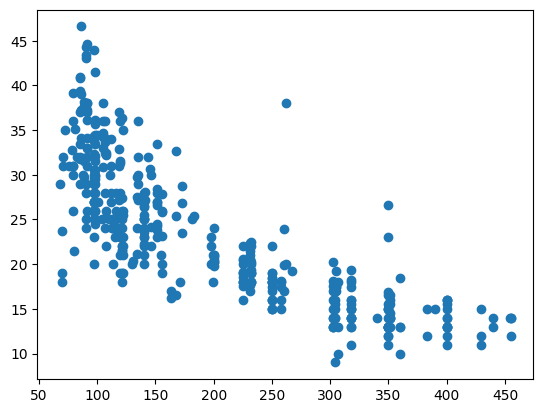

In [11]:
plt.scatter(datos['displacement'],datos['mpg'])

In [12]:
correlacion = datos['displacement'].corr(datos['mpg'])
correlacion

np.float64(-0.8042028248058979)

In [13]:
datos.keys()

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'car_name'],
      dtype='object')

In [26]:
datos = datos.dropna( subset=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year'] )
datos.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


In [27]:
X = datos[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']]
Y = datos['mpg']

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [29]:
# Crear el modelo
modelo = LinearRegression()
modelo.fit(X_train,Y_train)

LinearRegression()

In [30]:
modelo.intercept_

np.float64(-15.057758585282361)

In [32]:
modelo.coef_

array([-0.116173  ,  0.00101347, -0.00227634, -0.00656101,  0.06173551,
        0.76063644])

In [33]:
# Pongamolo a funcionar
predicciones = modelo.predict(X_test)

In [34]:
mean_absolute_error(Y_test, predicciones)

2.5038600897761283

In [37]:
mean_squared_error(Y_test, predicciones)

10.502370329417325

In [38]:
r2_score(Y_test, predicciones)

0.7942349075428586

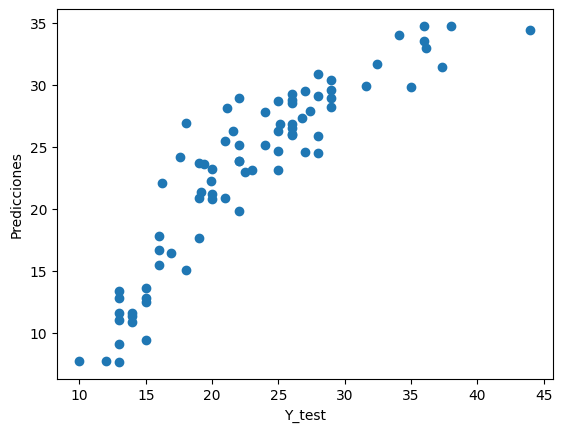

In [40]:
plt.scatter(Y_test, predicciones)
plt.xlabel('Y_test')
plt.ylabel('Predicciones')
plt.show()

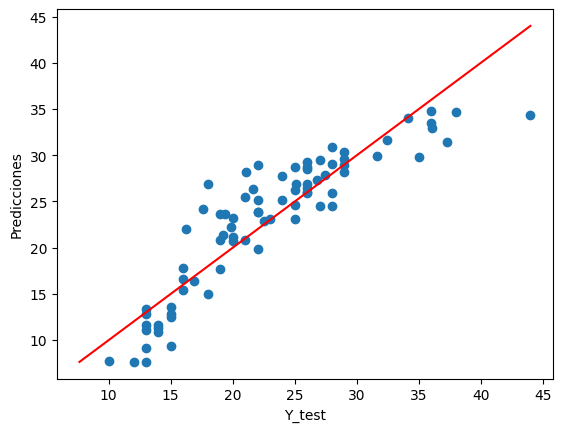

In [41]:
# Vamos a ajustar las escalas
minimo = min(
    Y_test.min(),
    predicciones.min()
)

maximo = max(
    Y_test.max(),
    predicciones.max()
)

plt.scatter(Y_test, predicciones)
plt.xlabel('Y_test')
plt.ylabel('Predicciones')
plt.plot([minimo, maximo], [minimo, maximo], color='red')
plt.show()